In [14]:
import pandas as pd
#Data Processing
patients = pd.read_csv('patients.csv')
diagnoses = pd.read_csv('diagnoses.csv')
outcomes = pd.read_csv('outcomes.csv')
labs = pd.read_csv('labs.csv')

In [15]:
patients = patients.merge(diagnoses, on = 'DiagnosisID')
patients = patients.merge(outcomes, on = 'OutcomeID')

In [16]:
patients['AdmissionDate']= pd.to_datetime(patients['AdmissionDate'])
patients['DischargeDate']= pd.to_datetime(patients['DischargeDate'])
patients['LengthOfStay'] = (patients['DischargeDate'] - patients['AdmissionDate']).dt.days

In [18]:
patients['OutcomeEncoded'] = patients['OutcomeName'].map({'Recovered': 0, 'Complicated': 1, 'Deceased': 1})

In [21]:
import numpy as np

patients['HighRisk'] = np.where(
	(patients['Age'] > 65)
	| (patients['OutcomeName'].isin(['Complicated', 'Deceased'])),
	1,
	0,
)

In [22]:
abnormal_conditions = {
    'Blood Sugar': lambda x: x > 120,
    'Cholesterol': lambda x: x > 200,   # ✅ fixed
    'Hemoglobin': lambda x: x < 13,     # ✅ fixed
}

def count_abnormal_labs(patient_id):
    patient_labs = labs[labs['PatientID'] == patient_id]   # ✅ fix column name
    count = 0

    for test_name, condition in abnormal_conditions.items():
        test_results = patient_labs[patient_labs['TestName'] == test_name]  # ✅ fix column name
        
        count += test_results['Result'].apply(condition).sum()

    return count   # ✅ outside loop

patients['AbnormalLabCount'] = patients['PatientID'].apply(count_abnormal_labs)

Model Training

In [25]:
features = patients[['Age', 'LengthOfStay', 'TreatmentCost', 'AbnormalLabCount']]
target = patients['OutcomeEncoded']

In [43]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)

In [46]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

ML-
1. SUPERVISED - input + output - linear-Regrssion,logistic Regression etc
2. unsupervised - input
3. reinforcement = rewards

In [48]:
# Correct variable names (match how you split the data)
y_pred = model.predict(x_test)  # lowercase x_test

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.71      0.95      0.81        43

    accuracy                           0.68        60
   macro avg       0.35      0.48      0.41        60
weighted avg       0.51      0.68      0.58        60



ROC CURVE

In [50]:
import matplotlib.pyplot as plt

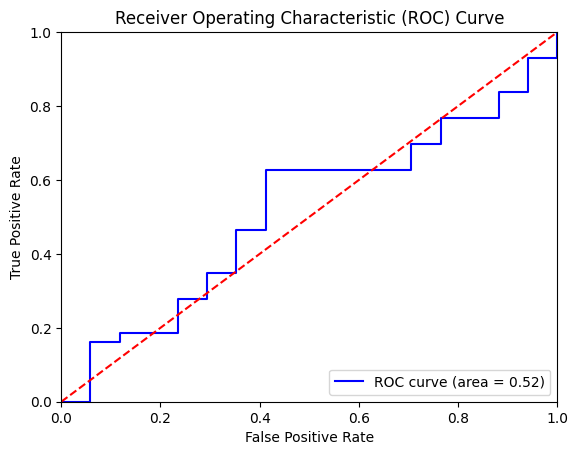

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc  
y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', label= f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red',linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [52]:
import joblib
joblib.dump(model, 'risk_model.ipynb')

['risk_model.ipynb']

In [53]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp314-cp314-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.1 MB 2.5 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/9.1 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 4.2/9.1 MB 5.6 MB/s eta 0:00:01
   -------------------------- ------------- 6.0/9.1 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 7.6/9.1 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.1 MB 6.7 MB/s eta 0:00:01
   -----------------------------

  You can safely remove it manually.


In [54]:
import streamlit as st
import pandas as pd
import joblib
model = joblib.load('risk_model.ipynb') # Load the trained model
st.title("Healthcare Risk stratification App")  
age = st.number_input("Age", min_value=0)
Length_of_stay = st.number_input("Length of Stay (days)", min_value=0)
Treatment_cost = st.number_input("Treatment Cost ($)", min_value=0.0)

if st.button("Predict"):
    input_data = pd.DataFrame({
        'Age': [age],
        'LengthOfStay': [Length_of_stay],
        'TreatmentCost': [Treatment_cost],
    })
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.write(f"Risk Prediction: {'High Risk' if prediction == 1 else 'Low'}")
    st.write(f"Probability: {round(probability, 2)}")

2026-03-31 11:07:44.921 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-31 11:07:45.603 
  command:

    streamlit run C:\Users\rohit\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-31 11:07:45.605 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-31 11:07:45.606 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-31 11:07:45.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-31 11:07:45.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-31 11:07:45.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-31 11:07:45.613 Thre